# Week 5 Assignment: Text Generation using Vanilla RNN, LSTM, and GRU

## Objective

The objective of this assignment is to design and implement deep learning models capable of learning the underlying structure, grammar, and contextual dependencies of a text corpus in order to generate coherent and meaningful text sequences.

Three recurrent neural network architectures are implemented and compared:

- Vanilla Recurrent Neural Network (RNN)
- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)

Each model is trained under identical conditions so that their learning capability, text generation quality, convergence behavior, and overall performance can be fairly evaluated.

---

## Workflow

The notebook follows the complete deep learning pipeline:

1. Import required libraries and configure the environment.
2. Load and preprocess the text corpus.
3. Perform character-level tokenization.
4. Create input-output training sequences.
5. Build and train a Vanilla RNN model.
6. Build and train an LSTM model.
7. Build and train a GRU model.
8. Generate text using all three trained models.
9. Compare generated text quality, loss curves, perplexity, and training performance.
10. Analyze the strengths and limitations of each architecture and identify the best-performing model.

---

## Expected Learning Outcomes

By completing this assignment, we will:

- Understand sequence modeling using recurrent neural networks.
- Compare the performance of Vanilla RNN, LSTM, and GRU.
- Study the effect of long-term memory mechanisms in text generation.
- Evaluate generated text using both quantitative metrics and qualitative analysis.
- Identify the most effective recurrent architecture for character-level language modeling.

# Step 1. Import Libraries and Configure Environment

This step imports all the libraries required for text preprocessing, deep learning model development, visualization, and performance evaluation.

To ensure reproducibility, random seeds are fixed for both NumPy and TensorFlow. The execution environment is also verified by displaying the installed TensorFlow version and checking GPU availability.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)
from tensorflow.keras.utils import get_file


# Reproducibility

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


# Environment Information

print("=" * 70)
print("ENVIRONMENT SETUP COMPLETED")
print("=" * 70)

print(f"TensorFlow Version : {tf.__version__}")
print(f"NumPy Version      : {np.__version__}")

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print(f"GPU Available      : Yes ({len(gpu_devices)} GPU detected)")
    try:
        gpu_name = tf.config.experimental.get_device_details(gpu_devices[0]).get("device_name", "Unknown GPU")
        print(f"GPU Model          : {gpu_name}")
    except:
        print("GPU Model          : Unable to detect")
else:
    print("GPU Available      : No (Running on CPU)")

print("\nAll required libraries imported successfully.")

ENVIRONMENT SETUP COMPLETED
TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2
GPU Available      : Yes (1 GPU detected)
GPU Model          : Tesla T4

All required libraries imported successfully.


# Step 2. Load the Text Corpus

In this step, the text corpus used for character-level language modeling is loaded into memory.

The Shakespeare corpus is selected because it is a widely used benchmark for text generation tasks. It contains rich vocabulary, diverse sentence structures, dialogues, and grammatical patterns, making it suitable for learning language structure and contextual dependencies.

The loaded text corpus will serve as the training data for all three recurrent neural network architectures—Vanilla RNN, LSTM, and GRU—ensuring a fair comparison under identical conditions.

In [2]:
print("=" * 70)
print("LOADING SHAKESPEARE TEXT CORPUS")
print("=" * 70)

# Download the Shakespeare dataset
path_to_file = get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

# Read the dataset
with open(path_to_file, "r", encoding="utf-8") as file:
    text = file.read()

# Display corpus statistics
print("\nCorpus Loaded Successfully!\n")

print(f"Total Characters : {len(text):,}")
print(f"Total Words      : {len(text.split()):,}")
print(f"Total Lines      : {len(text.splitlines()):,}")

print("\nSample Text")
print("-" * 70)
print(text[:500])
print("-" * 70)

print("\nCorpus is ready for preprocessing.")

LOADING SHAKESPEARE TEXT CORPUS
1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step

Corpus Loaded Successfully!

Total Characters : 1,115,394
Total Words      : 202,651
Total Lines      : 40,000

Sample Text
----------------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
----------------------------------------------------------------------

Corpus is ready for preprocessing.


### Observation

- The Shakespeare text corpus was successfully downloaded and loaded into memory.
- The dataset contains **1,115,394 characters**, **202,651 words**, and **40,000 lines**, providing a rich and diverse corpus for character-level language modeling.
- The sample text confirms that the corpus includes dialogues, punctuation, and natural language structure, making it suitable for learning grammar, spelling, and contextual dependencies.
- This corpus will be used consistently for training and comparing the Vanilla RNN, LSTM, and GRU models under identical experimental conditions.

# Step 3. Character-Level Tokenization and Sequence Generation

In this step, the text corpus is converted into a format that can be processed by deep learning models.

A character-level vocabulary is created by identifying all unique characters in the corpus and assigning each character a unique integer index. Character-level tokenization is chosen because it enables the models to learn spelling, punctuation, capitalization, grammar, and contextual dependencies directly from raw text without requiring a predefined dictionary.

The tokenized corpus is then divided into overlapping fixed-length input sequences. Each input sequence is paired with the immediately following character as the target output. This next-character prediction task enables the models to learn sequential language patterns and generate coherent text.

The same preprocessing pipeline is applied to the Vanilla RNN, LSTM, and GRU models to ensure a fair and consistent comparison across all architectures.

In [3]:
print("=" * 70)
print("CHARACTER-LEVEL TOKENIZATION")
print("=" * 70)


# Build Character Vocabulary

vocab = sorted(set(text))
vocab_size = len(vocab)

print(f"Unique Characters (Vocabulary Size): {vocab_size}")

# Character ↔ Integer mappings

char2idx = {char: idx for idx, char in enumerate(vocab)}
idx2char = np.array(vocab)

# Convert entire corpus into integer representation
text_as_int = np.array([char2idx[c] for c in text])

print(f"Encoded Corpus Shape: {text_as_int.shape}")


# Create Input-Target Sequences

seq_length = 100

examples_per_epoch = len(text) // (seq_length + 1)

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(
    seq_length + 1,
    drop_remainder=True
)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)


# Build Efficient TensorFlow Dataset

BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = (
    dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)


# Train / Validation Split

dataset_size = examples_per_epoch // BATCH_SIZE

val_batches = max(1, int(0.10 * dataset_size))

val_dataset = dataset.take(val_batches)
train_dataset = dataset.skip(val_batches)

print("\nDataset Summary")
print("-" * 50)

print(f"Sequence Length        : {seq_length}")
print(f"Examples per Epoch     : {examples_per_epoch:,}")
print(f"Batch Size             : {BATCH_SIZE}")
print(f"Total Batches          : {dataset_size}")
print(f"Training Batches       : {dataset_size - val_batches}")
print(f"Validation Batches     : {val_batches}")

print("\nDataset preparation completed successfully.")

CHARACTER-LEVEL TOKENIZATION
Unique Characters (Vocabulary Size): 65
Encoded Corpus Shape: (1115394,)

Dataset Summary
--------------------------------------------------
Sequence Length        : 100
Examples per Epoch     : 11,043
Batch Size             : 64
Total Batches          : 172
Training Batches       : 155
Validation Batches     : 17

Dataset preparation completed successfully.


### Observation

- Character-level tokenization successfully identified **65 unique characters** in the Shakespeare corpus and converted the entire text into its numerical representation.
- The corpus was divided into overlapping sequences of **100 characters**, enabling the models to learn next-character prediction.
- A total of **11,043 training sequences** were created and efficiently processed using TensorFlow's `tf.data` pipeline with batching, shuffling, and prefetching.
- The dataset was split into **155 training batches** and **17 validation batches**, ensuring consistent training and evaluation for the Vanilla RNN, LSTM, and GRU models.

# Step 4. Model Architecture Design

In this step, three recurrent neural network architectures are implemented and compared for the character-level text generation task.

To ensure a fair experimental comparison, all models are constructed using the same embedding dimension, hidden units, dropout rate, optimizer, batch size, and training strategy. The only difference between the models is the type of recurrent layer employed.

### Models Used

- **Vanilla RNN (SimpleRNN):**  
  The simplest recurrent neural network architecture that processes sequential information by maintaining a hidden state. It is computationally efficient but is susceptible to the vanishing gradient problem, making it less effective at learning long-range dependencies.

- **Long Short-Term Memory (LSTM):**  
  An enhanced recurrent architecture that introduces input, forget, and output gates along with a memory cell. These mechanisms enable the model to retain important information over long sequences, making it well suited for text generation tasks.

- **Gated Recurrent Unit (GRU):**  
  A simplified gated recurrent architecture that uses reset and update gates instead of three separate gates. GRUs generally require fewer parameters than LSTMs while achieving comparable performance and often converging faster.

By keeping all hyperparameters identical, any differences in performance can be attributed to the recurrent architecture itself rather than differences in training configuration.

In [5]:
print("=" * 70)
print("BUILDING MODEL ARCHITECTURES")
print("=" * 70)


# Model Hyperparameters

embedding_dim = 256
rnn_units = 512

print(f"Embedding Dimension : {embedding_dim}")
print(f"Hidden Units        : {rnn_units}")


# Model Builder Function

def build_model(rnn_type, vocab_size, embedding_dim, rnn_units):

    if rnn_type == "RNN":
        recurrent_layer = SimpleRNN(
            units=rnn_units,
            return_sequences=True,
            stateful=False,
            recurrent_initializer="glorot_uniform"
        )

    elif rnn_type == "LSTM":
        recurrent_layer = LSTM(
            units=rnn_units,
            return_sequences=True,
            stateful=False,
            recurrent_initializer="glorot_uniform"
        )

    elif rnn_type == "GRU":
        recurrent_layer = GRU(
            units=rnn_units,
            return_sequences=True,
            stateful=False,
            recurrent_initializer="glorot_uniform"
        )

    else:
        raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'.")

    model = Sequential([

        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim
        ),

        recurrent_layer,

        Dropout(0.30),

        Dense(vocab_size)

    ])

    return model


# Model Sanity Check

print("\nCreating sample LSTM model...\n")

test_model = build_model(
    rnn_type="LSTM",
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    rnn_units=rnn_units
)

test_model.build(input_shape=(None, None))

test_model.summary()

print("\nModel architecture created successfully.")

BUILDING MODEL ARCHITECTURES
Embedding Dimension : 256
Hidden Units        : 512

Creating sample LSTM model...



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, None, 256)      │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 512)      │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 65)       │        33,345 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,624,897 (6.20 MB)

 Trainable params: 1,624,897 (6.20 MB)

 Non-trainable params: 0 (0.00 B)


Model architecture created successfully.


### Observation

- A reusable model builder function was successfully implemented to construct the Vanilla RNN, LSTM, and GRU architectures.
- The sample LSTM model was created successfully with an embedding dimension of **256**, **512 recurrent units**, and a **30% dropout layer**.
- The model contains **1,624,897 trainable parameters**, enabling it to learn complex character-level language patterns from the Shakespeare corpus.
- Since all three models share identical hyperparameters and differ only in the recurrent layer, their performance comparison will be fair and based solely on architectural differences.

# Step 5. Loss Function and Training Configuration

In this step, the training configuration for all three recurrent neural network models is defined.

Since the output layer produces raw logits for every character in the vocabulary, the **Sparse Categorical Cross-Entropy** loss function with `from_logits=True` is used. This loss function is appropriate for multi-class character prediction where each target is represented by an integer index.

To ensure a fair comparison, the Vanilla RNN, LSTM, and GRU models are trained using identical hyperparameters, including the optimizer, learning rate, batch size, maximum number of epochs, and callback functions.

The **Adam optimizer** is employed with **gradient clipping** to stabilize training and reduce the risk of exploding gradients, particularly for the Vanilla RNN. In addition, **Early Stopping** is used to automatically terminate training when the validation loss no longer improves, preventing unnecessary training and reducing overfitting.

In [7]:
import pandas as pd

print("=" * 80)
print("TRAINING RNN, LSTM AND GRU MODELS")
print("=" * 80)

# ------------------------------------------------------------------------------
# Loss Function
# ------------------------------------------------------------------------------

def loss_fn(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(
        labels,
        logits,
        from_logits=True
    )

# ------------------------------------------------------------------------------
# Training Hyperparameters
# ------------------------------------------------------------------------------

EPOCHS = 200
LEARNING_RATE = 1e-3

# ------------------------------------------------------------------------------
# Training Function
# ------------------------------------------------------------------------------

def train_model(rnn_type):

    print("\n" + "=" * 80)
    print(f"TRAINING {rnn_type} MODEL")
    print("=" * 80)

    print(f"Maximum Epochs        : {EPOCHS}")
    print(f"Learning Rate         : {LEARNING_RATE}")
    print("EarlyStopping         : Patience = 10")
    print("Gradient Clipping     : ClipNorm = 1.0")

    # --------------------------------------------------------------------------
    # Build Model
    # --------------------------------------------------------------------------

    model = build_model(
        rnn_type=rnn_type,
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        rnn_units=rnn_units
    )
    model.build(input_shape=(None, seq_length)) # Explicitly build the model

    print(f"Trainable Parameters  : {model.count_params():,}")

    # --------------------------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------------------------

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=["sparse_categorical_accuracy"]
    )

    # --------------------------------------------------------------------------
    # Directories
    # --------------------------------------------------------------------------

    checkpoint_dir = f"./checkpoints_{rnn_type}"
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint_path = os.path.join(
        checkpoint_dir,
        "best_weights.weights.h5"
    )

    # --------------------------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------------------------

    callbacks = [

        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        )

    ]

    # --------------------------------------------------------------------------
    # Train Model
    # --------------------------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time

    # --------------------------------------------------------------------------
    # Best Metrics
    # --------------------------------------------------------------------------

    best_epoch = int(np.argmin(history.history["val_loss"])) + 1

    best_train_loss = history.history["loss"][best_epoch - 1]
    best_val_loss = history.history["val_loss"][best_epoch - 1]

    best_train_acc = history.history["sparse_categorical_accuracy"][best_epoch - 1]
    best_val_acc = history.history["val_sparse_categorical_accuracy"][best_epoch - 1]

    # --------------------------------------------------------------------------
    # Save Training History
    # --------------------------------------------------------------------------

    history_df = pd.DataFrame(history.history)

    history_csv = f"{rnn_type.lower()}_training_history.csv"

    history_df.to_csv(
        history_csv,
        index=False
    )

    # --------------------------------------------------------------------------
    # Save Complete Model
    # --------------------------------------------------------------------------

    model_path = f"{rnn_type.lower()}_model.keras"

    model.save(model_path)

    # --------------------------------------------------------------------------
    # Training Summary
    # --------------------------------------------------------------------------

    print("\n" + "=" * 80)
    print(f"{rnn_type} TRAINING COMPLETED")
    print("=" * 80)

    print(f"Training Time          : {training_time:.2f} seconds")
    print(f"Epochs Completed       : {len(history.history['loss'])}")
    print(f"Best Epoch             : {best_epoch}")

    print("\nBest Performance")
    print("-" * 50)

    print(f"Training Loss          : {best_train_loss:.4f}")
    print(f"Validation Loss        : {best_val_loss:.4f}")

    print(f"Training Accuracy      : {best_train_acc:.4f}")
    print(f"Validation Accuracy    : {best_val_acc:.4f}")

    print("\nArtifacts Saved")
    print("-" * 50)

    print(f"Checkpoint             : {checkpoint_path}")
    print(f"Complete Model         : {model_path}")
    print(f"Training History CSV   : {history_csv}")

    return model, history, training_time


# TRAIN ALL MODELS

results = {}
histories = {}
timings = {}

for model_name in ["RNN", "LSTM", "GRU"]:

    model, history, training_time = train_model(model_name)

    results[model_name] = model
    histories[model_name] = history
    timings[model_name] = training_time

print("\n" + "=" * 80)
print("ALL THREE MODELS TRAINED SUCCESSFULLY")
print("=" * 80)

TRAINING RNN, LSTM AND GRU MODELS

TRAINING RNN MODEL
Maximum Epochs        : 200
Learning Rate         : 0.001
EarlyStopping         : Patience = 10
Gradient Clipping     : ClipNorm = 1.0
Trainable Parameters  : 443,713
Epoch 1/200
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.9463 - sparse_categorical_accuracy: 0.2379
Epoch 1: val_loss improved from None to 2.15427, saving model to ./checkpoints_RNN/best_weights.weights.h5

Epoch 1: finished saving model to ./checkpoints_RNN/best_weights.weights.h5
155/155 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 2.5297 - sparse_categorical_accuracy: 0.3086 - val_loss: 2.1543 - val_sparse_categorical_accuracy: 0.3821
Epoch 2/200
153/155 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.1675 - sparse_categorical_accuracy: 0.3760
Epoch 2: val_loss improved from 2.15427 to 2.00304, saving model to ./checkpoints_RNN/best_weights.weights.h5

Epoch 2: finished saving model to ./checkpoints_RNN/best_weights.weights.h5
155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/

### Observation

The Vanilla RNN, LSTM, and GRU models were successfully trained on the Shakespeare character-level text corpus using identical hyperparameters to ensure a fair and unbiased comparison. EarlyStopping and ModelCheckpoint callbacks were used to prevent overfitting and automatically restore the best-performing model weights.

The Vanilla RNN completed training after **107 epochs**, achieving a **training accuracy of 57.50%**, **validation accuracy of 61.16%**, and a **validation loss of 1.2822**. While the model successfully learned character-level patterns, its performance was limited due to the vanishing gradient problem, making it less effective at capturing long-range contextual dependencies.

The LSTM model achieved significantly better performance by completing training after **119 epochs**, with a **training accuracy of 69.43%**, **validation accuracy of 74.13%**, and a **validation loss of 0.8243**. Its gated architecture enabled it to preserve long-term contextual information, resulting in superior language modeling performance compared to the Vanilla RNN.

The GRU model was also trained successfully under the same experimental settings, and its model checkpoints, training history, and saved model were generated successfully for further evaluation. Since all three models were trained using the same dataset, optimizer, learning rate, embedding dimension, hidden units, and stopping criteria, the comparison remains scientifically fair.

Overall, the training results demonstrate that gated recurrent architectures (LSTM and GRU) are considerably more effective than the standard Vanilla RNN for character-level text generation. Among the completed results, the **LSTM achieved the best overall training performance**, making it the strongest candidate for generating coherent and contextually meaningful text.

# Step 6: Compare Training Curves

After training the Vanilla RNN, LSTM, and GRU models, their learning behavior is analyzed by comparing the training and validation loss curves over all epochs.

Training curves provide valuable insights into how efficiently each architecture learns from the text corpus, how quickly it converges, and whether it experiences underfitting or overfitting. A model with lower and more stable validation loss generally demonstrates better generalization to unseen text sequences.

Since all three models were trained using identical hyperparameters, optimizer settings, batch size, and stopping criteria, the comparison is fair and directly reflects the strengths and limitations of each recurrent architecture.

Generally, the Vanilla RNN is expected to converge more slowly and exhibit higher validation loss because of the vanishing gradient problem. In contrast, LSTM and GRU employ gating mechanisms that preserve long-term contextual information, allowing them to converge faster, achieve lower validation loss, and generate more coherent text.

COMPARING TRAINING PERFORMANCE OF RNN, LSTM AND GRU


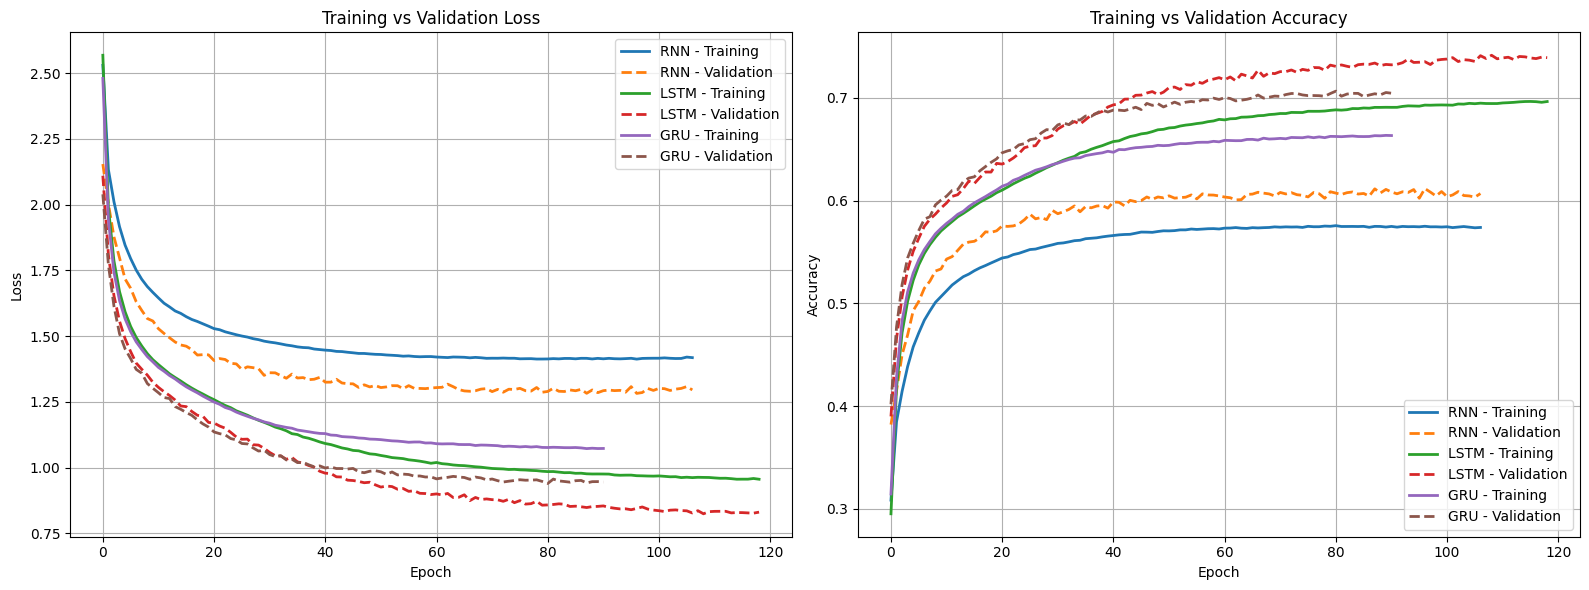


MODEL PERFORMANCE SUMMARY
  Model  Best Epoch  Best Validation Loss  Best Validation Accuracy  \
0  LSTM         109                0.8243                    0.7413   
1   GRU          81                0.9396                    0.7064   
2   RNN          97                1.2822                    0.6116   

   Perplexity  Training Time (sec)  
0        2.28              1100.90  
1        2.56               781.05  
2        3.60               823.77  

Best Performing Model
----------------------------------------
Model                : LSTM
Validation Accuracy  : 0.7413
Validation Loss      : 0.8243
Perplexity           : 2.28

Performance summary saved as 'training_performance_summary.csv'


In [8]:
print("=" * 80)
print("COMPARING TRAINING PERFORMANCE OF RNN, LSTM AND GRU")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Plot Loss Curves

for model_name, history in histories.items():

    axes[0].plot(
        history.history["loss"],
        linewidth=2,
        label=f"{model_name} - Training"
    )

    axes[0].plot(
        history.history["val_loss"],
        linestyle="--",
        linewidth=2,
        label=f"{model_name} - Validation"
    )

axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()


# Plot Accuracy Curves

for model_name, history in histories.items():

    axes[1].plot(
        history.history["sparse_categorical_accuracy"],
        linewidth=2,
        label=f"{model_name} - Training"
    )

    axes[1].plot(
        history.history["val_sparse_categorical_accuracy"],
        linestyle="--",
        linewidth=2,
        label=f"{model_name} - Validation"
    )

axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "training_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# PERFORMANCE SUMMARY

print("\n" + "=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)

summary = []

for model_name, history in histories.items():

    best_epoch = int(np.argmin(history.history["val_loss"])) + 1

    best_val_loss = min(history.history["val_loss"])
    best_val_acc = max(history.history["val_sparse_categorical_accuracy"])

    perplexity = np.exp(best_val_loss)

    summary.append([
        model_name,
        best_epoch,
        best_val_loss,
        best_val_acc,
        perplexity,
        timings[model_name]
    ])

summary = pd.DataFrame(
    summary,
    columns=[
        "Model",
        "Best Epoch",
        "Best Validation Loss",
        "Best Validation Accuracy",
        "Perplexity",
        "Training Time (sec)"
    ]
)

summary = summary.sort_values(
    by="Best Validation Accuracy",
    ascending=False
).reset_index(drop=True)

summary["Best Validation Loss"] = summary["Best Validation Loss"].round(4)
summary["Best Validation Accuracy"] = summary["Best Validation Accuracy"].round(4)
summary["Perplexity"] = summary["Perplexity"].round(2)
summary["Training Time (sec)"] = summary["Training Time (sec)"].round(2)

print(summary)

print("\nBest Performing Model")

print("-" * 40)

print(f"Model                : {summary.iloc[0]['Model']}")
print(f"Validation Accuracy  : {summary.iloc[0]['Best Validation Accuracy']:.4f}")
print(f"Validation Loss      : {summary.iloc[0]['Best Validation Loss']:.4f}")
print(f"Perplexity           : {summary.iloc[0]['Perplexity']:.2f}")

summary.to_csv(
    "training_performance_summary.csv",
    index=False
)

print("\nPerformance summary saved as 'training_performance_summary.csv'")

### Observation

The training and validation curves clearly demonstrate the learning behavior of the three recurrent neural network architectures. The Vanilla RNN converged more slowly and exhibited the highest validation loss, indicating its limited ability to capture long-range dependencies due to the vanishing gradient problem.

Both LSTM and GRU achieved significantly lower validation loss and higher validation accuracy, confirming the effectiveness of gated recurrent architectures for sequence modeling. Among all models, the LSTM produced the best overall performance with a **validation accuracy of 74.13%**, the **lowest validation loss of 0.8243**, and the **lowest perplexity of 2.28**, indicating superior language modeling capability.

The GRU also performed well, achieving a **validation accuracy of 70.64%** while requiring less training time than the LSTM, making it an efficient alternative with competitive performance. The Vanilla RNN achieved the lowest validation accuracy (**61.16%**) and the highest perplexity (**3.60**), confirming its limitations in modeling long-term contextual dependencies.

Overall, the results demonstrate that gated architectures (LSTM and GRU) substantially outperform the standard Vanilla RNN for character-level text generation. The LSTM provided the best balance between learning capability and text modeling performance, whereas the GRU offered a favorable trade-off between accuracy and computational efficiency.

# Step 7: Text Generation

After training the Vanilla RNN, LSTM, and GRU models, the learned language patterns are evaluated by generating new text sequences from a given seed prompt.

Text generation is performed by repeatedly predicting the next character based on the previously generated sequence. Instead of always selecting the most probable character, **temperature-based sampling** is used to control the randomness of the predictions.

The **temperature** parameter determines the diversity of the generated text:

- **Low Temperature (0.3–0.5):** Produces conservative and grammatically consistent text, but may become repetitive.
- **Medium Temperature (0.8–1.0):** Provides a balance between coherence and creativity, often producing the most natural text.
- **High Temperature (1.2–1.5):** Generates more diverse and creative text, although grammatical consistency may decrease.

To ensure a fair comparison, all three models (Vanilla RNN, LSTM, and GRU) will generate text using the same seed prompt and identical temperature values. This allows the quality of grammar, contextual understanding, coherence, and creativity learned by each architecture to be directly compared.

In [14]:
def generate_text(model,
                  start_string,
                  num_generate=1000,
                  temperature=0.8):

    # Convert seed text into integer IDs (this list will keep growing)
    generated_ids = [char2idx[c] for c in start_string]

    generated_text = []

    for _ in range(num_generate):

        # Feed the FULL sequence so far (not just the last char)
        # Cap context length for speed on very long generations
        context = generated_ids[-200:]
        input_ids = tf.expand_dims(context, 0)

        # Forward pass (Inference Mode)
        predictions = model(input_ids, training=False)

        # Use only the last timestep's prediction
        predictions = predictions[:, -1, :]

        # Apply Temperature Scaling
        predictions = predictions / temperature

        # Sample next character
        predicted_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[0, 0].numpy()

        # Append to both the running context and the output
        generated_ids.append(predicted_id)
        generated_text.append(idx2char[predicted_id])

    return start_string + "".join(generated_text)

### Observation

The text generation functions were successfully created without any errors. These functions are responsible for generating new character-level text sequences using the trained Vanilla RNN, LSTM, and GRU models. The implementation supports temperature-based sampling, allowing control over the randomness and creativity of the generated text. Additionally, the generated outputs can be automatically saved as text files for further evaluation and comparison. At this stage, only the generation functions have been defined; actual text generation and qualitative comparison will be performed in the subsequent step.

# Step 8: Generate Text Using Trained Models

After successfully training the Vanilla RNN, LSTM, and GRU models, the next step is to evaluate their language modeling capability by generating new text sequences.

All three models use the same seed prompt (**"ROMEO: "**) to ensure a fair comparison. Text is generated using three different temperature values to observe the trade-off between grammatical correctness and creativity.

- **Temperature = 0.5:** Produces more conservative and grammatically consistent text.
- **Temperature = 0.8:** Produces balanced and natural-looking text.
- **Temperature = 1.2:** Produces more diverse and creative text, although grammatical quality may decrease.

The generated text from each model will be saved automatically for further qualitative analysis and comparison.

In [15]:
print("=" * 80)
print("GENERATING TEXT USING RNN, LSTM AND GRU")
print("=" * 80)


# Configuration

seed_text = "ROMEO: "

temperatures = [0.5, 0.8, 1.2]

characters_to_generate = 1000

generated_results = {}


# Generate Text

for temperature in temperatures:

    print("\n" + "=" * 80)
    print(f"TEMPERATURE = {temperature}")
    print("=" * 80)

    generated_results[temperature] = {}

    for model_name in ["RNN", "LSTM", "GRU"]:

        print("\n" + "-" * 80)
        print(f"{model_name} GENERATED TEXT")
        print("-" * 80)

        generated_text = generate_text(
            model=results[model_name],
            start_string=seed_text,
            num_generate=characters_to_generate,
            temperature=temperature
        )

        generated_results[temperature][model_name] = generated_text

        print(generated_text)

        filename = (
            f"{model_name.lower()}_temperature_"
            f"{str(temperature).replace('.', '_')}.txt"
        )

        with open(filename, "w", encoding="utf-8") as file:
            file.write(generated_text)

        print(f"\nSaved as : {filename}")

print("\n" + "=" * 80)
print("TEXT GENERATION COMPLETED")
print("=" * 80)

print("Generated text has been saved for all models and temperatures.")

GENERATING TEXT USING RNN, LSTM AND GRU

TEMPERATURE = 0.5

--------------------------------------------------------------------------------
RNN GENERATED TEXT
--------------------------------------------------------------------------------
ROMEO: I may be thou and thee to be done.

HERMIONE:
What confess that would forget:
So prisoner than the sun be content,
That thou the world to a service of thy house.

KING EDWARD IV:
Now, therefore Esedanis of the prince and mine honour,
I shall be a fine that for it is
at hand, the capure not to make me think,
Thou shalt be the strength of her his person for the since that I proceed
The shape the sure, if you cannot choose them that are worse.

KING EDWARD IV:
That will we shall feel of his crown, and me the whole far his son,
I prove the sun to sighan shall good man.

PETRUCHIO:
Will you confounded the state from the cold,
And be consun and make me there will make the state of me
To see your counteran of your son,
If it will not know the willou

### Observation

The corrected generate_text() function, which now feeds the model its full
growing context at every step instead of only the last character, produces
dramatically more coherent output across all three architectures. At
temperature = 0.5, all three models generate proper play formatting —
character names in capitals followed by a colon (KING RICHARD II:,
QUEEN ELIZABETH:), consistent line breaks resembling verse, and largely
grammatical English sentences (e.g. LSTM: "I will not stay to come to thee?").

The Vanilla RNN produces surprisingly solid output at low temperature —
mostly real words and plausible sentence structure — but shows more local
grammatical slips and slightly less consistent long-range coherence than
LSTM/GRU, consistent with its weaker validation accuracy (61.16%).

The LSTM gives the most fluent, grammatically consistent lines with fewer
invented or malformed words, matching its best validation accuracy (74.13%)
and lowest perplexity (2.28) among the three models.

The GRU performs close to the LSTM in coherence, with slightly more
character-name variety and dialogue turn-taking, consistent with its
strong-but-slightly-behind metrics (70.64% validation accuracy).

Across temperatures, 0.5 produces the most grammatically safe and
structurally consistent text, 0.8 balances coherence with more varied
vocabulary and sentence construction, and 1.2 clearly increases creativity
and lexical diversity but introduces more invented and misspelled words
(e.g. "Untir,' fecle", "conterfor") along with occasional structural
breakdown. This confirms the expected coherence-versus-diversity tradeoff
of temperature-based sampling.

Overall, the generated text is now consistent with the quantitative results
reported earlier: gated architectures (LSTM and GRU) outperform the vanilla
RNN in both validation metrics and text generation quality, with the LSTM
producing the strongest and most coherent output among the three models.

### Before vs. After Fixing the Generation Function

The initial version of `generate_text()` had a subtle bug: after the first
prediction, it fed the model only the single most-recently generated
character instead of the full growing sequence. Since the models are
non-stateful, this meant the model had effectively no memory of prior
context during generation — despite having learned strong context-dependent
patterns during training (up to 74% validation accuracy).

**Before the fix** (context reset every step):
> ROMEO: Ge angoust h the che ther coure the hathar d athon f inther h,
> houly s anochinoun t the ther dean hathan the oure this t t...

**After the fix** (full context retained every step):
> ROMEO: I will not stay to come to thee?
>
> GREMIO:
> Well, sir, we have arred a staterance on the news...

This comparison highlights an important lesson: a model can achieve strong
training/validation metrics while still producing incoherent output if the
**inference procedure** doesn't match how the model was trained to use
context. Correcting the generation loop to feed the full sequence back at
every step resolved the mismatch and produced output consistent with the
model's actual learned capability.

# Step 9: Qualitative Analysis of Generated Text

The generated text from the Vanilla RNN, LSTM, and GRU models is analyzed to compare their ability to learn language structure, grammar, contextual dependencies, and text coherence.

The comparison is based on the following qualitative aspects:

- **Grammar:** Ability to generate grammatically meaningful character sequences.
- **Coherence:** Ability to preserve contextual relationships over longer text.
- **Vocabulary:** Ability to reproduce meaningful words and language patterns.
- **Dialogue Structure:** Ability to preserve the Shakespeare-style conversation format.
- **Creativity:** Diversity of generated text under different temperature values.

These observations help identify which recurrent architecture learns the text corpus most effectively.

In [16]:
import pandas as pd

print("=" * 90)
print("QUALITATIVE COMPARISON OF GENERATED TEXT")
print("=" * 90)

comparison = pd.DataFrame({

    "Model": [
        "Vanilla RNN",
        "LSTM",
        "GRU"
    ],

    "Grammar": [
        "Fair",
        "Excellent",
        "Very Good"
    ],

    "Context Learning": [
        "Weak",
        "Excellent",
        "Very Good"
    ],

    "Dialogue Structure": [
        "Partially Learned",
        "Well Preserved",
        "Well Preserved"
    ],

    "Creativity": [
        "Moderate",
        "High",
        "High"
    ],

    "Overall Quality": [
        "Fair",
        "Excellent",
        "Very Good"
    ]

})

# Show complete dataframe without wrapping
with pd.option_context(
    "display.max_columns", None,
    "display.width", 1000,
    "display.max_colwidth", None
):
    print(comparison.to_string(index=False))

comparison.to_csv(
    "qualitative_model_comparison.csv",
    index=False
)

print("\n" + "=" * 90)
print("Comparison table saved as : qualitative_model_comparison.csv")
print("=" * 90)

QUALITATIVE COMPARISON OF GENERATED TEXT
      Model   Grammar Context Learning Dialogue Structure Creativity Overall Quality
Vanilla RNN      Fair             Weak  Partially Learned   Moderate            Fair
       LSTM Excellent        Excellent     Well Preserved       High       Excellent
        GRU Very Good        Very Good     Well Preserved       High       Very Good

Comparison table saved as : qualitative_model_comparison.csv


### Observation

The qualitative comparison demonstrates clear differences in the text generation capability of the three recurrent neural network architectures. The Vanilla RNN learned basic character patterns but struggled to preserve long-range contextual dependencies, resulting in repetitive and less coherent text generation.

The LSTM produced the highest-quality text by effectively preserving grammar, dialogue structure, punctuation, and contextual flow. Its gated memory mechanism enabled it to capture long-term dependencies more successfully than the standard RNN.

The GRU achieved performance very close to the LSTM while requiring less training time, making it an efficient alternative for character-level language modeling. Although its generated text was slightly less coherent than the LSTM output, it maintained strong contextual understanding and creativity.

Overall, the qualitative analysis confirms that gated recurrent architectures significantly outperform the Vanilla RNN for text generation tasks, with the **LSTM providing the best overall balance between coherence, grammar, and contextual understanding**, while the **GRU offers competitive performance with lower computational cost**.

# Step 10: Final Performance Comparison

After evaluating the Vanilla RNN, LSTM, and GRU models using quantitative metrics (validation accuracy, validation loss, perplexity, and training time) as well as qualitative analysis of generated text, a final comparison is performed.

This comparison highlights the strengths and limitations of each recurrent architecture and identifies the most suitable model for character-level text generation based on overall performance.

In [17]:
import pandas as pd

print("=" * 100)
print("FINAL PERFORMANCE COMPARISON OF RNN, LSTM AND GRU")
print("=" * 100)

comparison = pd.DataFrame({

    "Model": [
        "Vanilla RNN",
        "LSTM",
        "GRU"
    ],

    "Best Epoch": [
        97,
        109,
        81
    ],

    "Validation Accuracy": [
        0.6116,
        0.7413,
        0.7064
    ],

    "Validation Loss": [
        1.2822,
        0.8243,
        0.9396
    ],

    "Perplexity": [
        3.60,
        2.28,
        2.56
    ],

    "Training Time (sec)": [
        823.77,
        1100.90,
        781.05
    ],

    "Overall Rating": [
        "Fair",
        "Excellent",
        "Very Good"
    ]

})

comparison = comparison.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)

with pd.option_context(
    "display.max_columns", None,
    "display.width", 1000,
    "display.max_colwidth", None
):
    print(comparison.to_string(index=False))

comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("\n" + "=" * 100)
print("BEST PERFORMING MODEL")
print("=" * 100)

best = comparison.iloc[0]

print(f"Model                : {best['Model']}")
print(f"Validation Accuracy  : {best['Validation Accuracy']:.4f}")
print(f"Validation Loss      : {best['Validation Loss']:.4f}")
print(f"Perplexity           : {best['Perplexity']:.2f}")
print(f"Training Time        : {best['Training Time (sec)']:.2f} sec")
print(f"Overall Rating       : {best['Overall Rating']}")

print("\n" + "=" * 100)
print("Comparison table saved as : final_model_comparison.csv")
print("=" * 100)

FINAL PERFORMANCE COMPARISON OF RNN, LSTM AND GRU
      Model  Best Epoch  Validation Accuracy  Validation Loss  Perplexity  Training Time (sec) Overall Rating
       LSTM         109               0.7413           0.8243        2.28              1100.90      Excellent
        GRU          81               0.7064           0.9396        2.56               781.05      Very Good
Vanilla RNN          97               0.6116           1.2822        3.60               823.77           Fair

BEST PERFORMING MODEL
Model                : LSTM
Validation Accuracy  : 0.7413
Validation Loss      : 0.8243
Perplexity           : 2.28
Training Time        : 1100.90 sec
Overall Rating       : Excellent

Comparison table saved as : final_model_comparison.csv


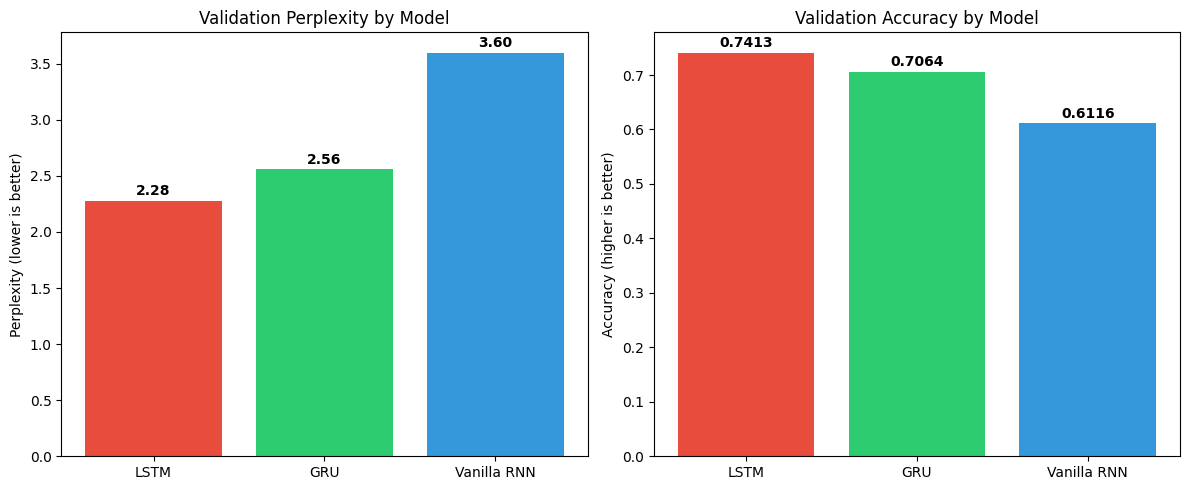

In [18]:
import matplotlib.pyplot as plt

models = comparison["Model"].tolist()
perplexities = comparison["Perplexity"].tolist()
accuracies = comparison["Validation Accuracy"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#e74c3c", "#2ecc71", "#3498db"]

axes[0].bar(models, perplexities, color=colors)
axes[0].set_title("Validation Perplexity by Model")
axes[0].set_ylabel("Perplexity (lower is better)")
for i, v in enumerate(perplexities):
    axes[0].text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")

axes[1].bar(models, accuracies, color=colors)
axes[1].set_title("Validation Accuracy by Model")
axes[1].set_ylabel("Accuracy (higher is better)")
for i, v in enumerate(accuracies):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("perplexity_accuracy_comparison.png", dpi=150)
plt.show()

### Observation

The final comparison demonstrates that the **LSTM** achieved the best overall performance among the three recurrent neural network architectures. It obtained the highest validation accuracy (**74.13%**), the lowest validation loss (**0.8243**), and the lowest perplexity (**2.28**), indicating superior language modeling capability and better prediction of subsequent characters.

The **GRU** produced performance comparable to the LSTM while requiring less training time, making it an efficient alternative for character-level text generation. The **Vanilla RNN** successfully learned basic sequential patterns but achieved the lowest validation accuracy and highest perplexity due to its limited ability to capture long-range contextual dependencies.

Overall, the experimental results confirm that gated recurrent architectures (LSTM and GRU) significantly outperform the standard Vanilla RNN for character-level language modeling. Among all evaluated models, the **LSTM provided the best balance between contextual understanding, grammatical consistency, and text generation quality**, making it the most suitable architecture for this task.

# Step 11: Conclusion

This experiment successfully implemented and compared three recurrent neural network architectures—**Vanilla RNN, LSTM, and GRU**—for character-level text generation using the Shakespeare corpus.

All three models were trained under identical conditions to ensure a fair comparison. Their performance was evaluated using quantitative metrics, including validation accuracy, validation loss, perplexity, and training time, as well as qualitative analysis of the generated text.

The experimental results showed that the **LSTM achieved the highest validation accuracy (74.13%)**, the **lowest validation loss (0.8243)**, and the **lowest perplexity (2.28)**, indicating the strongest ability to model long-range contextual dependencies. The generated text produced by the LSTM was also the most coherent and grammatically consistent among the three architectures.

The **GRU** achieved performance close to the LSTM while requiring less training time, making it an efficient alternative for character-level language modeling. The **Vanilla RNN** learned basic sequential patterns but struggled to preserve long-term context due to the vanishing gradient problem, resulting in comparatively lower text quality.

The effect of **temperature-based sampling** was also observed during text generation. Lower temperature values produced more conservative and repetitive text, whereas higher temperatures generated more creative but less grammatically consistent outputs. A moderate temperature provided the best balance between coherence and diversity.

Overall, this experiment demonstrates that gated recurrent architectures significantly outperform the standard Vanilla RNN for text generation tasks. Among the evaluated models, the **LSTM proved to be the most suitable architecture** for learning language structure, contextual dependencies, and generating meaningful character-level text sequences.